In [2]:
import random
# iris dataset from sklearn
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import numpy as np

data = load_iris()['data']
# Normalize each sample so distance is driven by direction/relative feature scale.
data = data/np.linalg.norm(data, axis=1).reshape(-1, 1)
data = [list(point) for point in list(data)]
targets = ["" for _ in range(len(data))]
num_clusters = 3
num_points = len(data)
num_features = len(data[0])


[[np.float64(0.7265305373146547), np.float64(0.3341266662395303), np.float64(0.5649710476308758), np.float64(0.19201808428455336)], [np.float64(0.8132767241752522), np.float64(0.5248793475074569), np.float64(0.24536278214932314), np.float64(0.03795365938999101)], [np.float64(0.789002855602604), np.float64(0.5696590595716082), np.float64(0.22345476447668133), np.float64(0.040402508798418356)]]
[2, 1, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
{2: [[np.float64(0.8037727730153805), np.float64(0.5516087657948691), np.float64(0.2206435063179476), np.float64(0.03152050090256395)], [np.float64(0.805

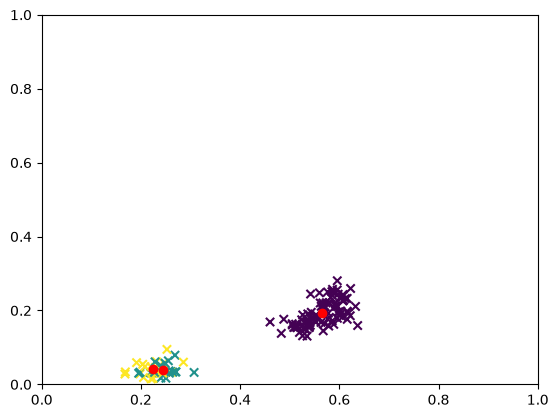

In [3]:
# 1) Initialization: pick K random data points as starting centroids.
centroids = random.sample(list(data), num_clusters)
for i in range(20):
    # 2) Assignment step: assign each point to its nearest centroid.
    closest_centroids={}
    for j , datum in enumerate(data):
        dist = []
        for centroid in centroids:
            distance = sum([(a-b)**2 for a,b in zip(datum, centroid)])
            dist.append(distance)
        
        # print(dist)
        
        closest_centroid = dist.index(min(dist))
        closest_centroids[closest_centroid] = closest_centroids.get(closest_centroid, []) + [datum]
        targets[j] = closest_centroid
        # print(f"datum {datum} assigned to centroid {closest_centroid} at {centroids[closest_centroid]}" )

    # 3) Update step: move each centroid to the mean of its assigned points.
    for x in  closest_centroids:
        new_centroid = ([sum(i)/len(closest_centroids[x]) for i in zip(*closest_centroids[x])])
        centroids[x] = new_centroid
    
    # 4) Convergence note: this version runs a fixed number of iterations (20)
    # instead of stopping early when centroid movement becomes very small.

print(centroids)
print(targets)
print(closest_centroids)

#marker style for each cluster

plt.scatter([i[2] for i in data], [i[3] for i in data], c=targets, marker='x')
plt.scatter([i[2] for i in centroids], [i[3] for i in centroids], c='r')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()
pass


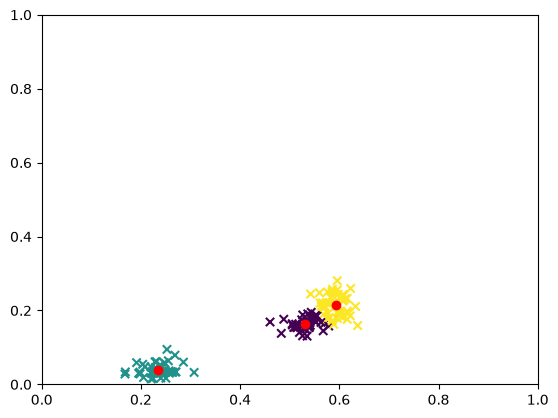

In [4]:
#use sklearn to do the same thing
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0).fit(data)
targets = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.scatter([i[2] for i in data], [i[3] for i in data], c=targets, marker='x')
plt.scatter([i[2] for i in centroids], [i[3] for i in centroids], c='r')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

In [5]:
# collaborative filtering, movie recommendation system, matrix factorization
movies = [
    "The Matrix",
    "Dune",
    "Titanic",
    "The Godfather",
    "The Shawshank Redemption"]

users = ["A", "B", "C"]

ratings = [
    [5, 4, 3, 4, 5],
    [4, 5, 4, 5, 4],
    [3, 4, 5, 4, 3]
]

n_embed = 4

import numpy as np
user_embeddings = np.random.rand(len(users), n_embed)
movie_embeddings = np.random.rand(len(movies), n_embed)

predicted_ratings = np.dot(user_embeddings, movie_embeddings.T)
rmse = np.sqrt(np.mean((predicted_ratings - ratings) ** 2))

print("RMSE:", rmse)

RMSE: 3.342996870562459


### Matrix Factorization Gradient Derivation

Let:
- $U \in \mathbb{R}^{n_u \times k}$ be user embeddings
- $V \in \mathbb{R}^{n_m \times k}$ be movie embeddings
- $R \in \mathbb{R}^{n_u \times n_m}$ be the rating matrix
- Predictions: $P = UV^T$

Define error matrix:
$$
E = P - R = UV^T - R
$$

MSE objective:
$$
L(U, V) = \frac{1}{n_u n_m}\|UV^T - R\|_F^2 = \frac{1}{n_u n_m}\|E\|_F^2
$$

Gradients:
$$
\frac{\partial L}{\partial U} = \frac{2}{n_u n_m}EV, \qquad
\frac{\partial L}{\partial V} = \frac{2}{n_u n_m}E^TU
$$

Gradient descent updates:
$$
U \leftarrow U - \alpha\frac{\partial L}{\partial U}, \qquad
V \leftarrow V - \alpha\frac{\partial L}{\partial V}
$$

Notes for the implementation below:
- RMSE is used for logging.
- The code uses a scaled/averaged gradient form and absorbs constant factors into learning rate $\alpha$.

In [6]:
# Minimize RMSE by learning user/movie embeddings with gradient descent.
#
learning_rate = 0.01

# Convert ratings to ndarray once so shapes and arithmetic are explicit.
ratings_matrix = np.array(ratings, dtype=float)

for epoch in range(1000):
    # Forward pass: P = U V^T
    predicted_ratings = np.dot(user_embeddings, movie_embeddings.T)

    # Error matrix: E = P - R
    error = predicted_ratings - ratings_matrix

    # Monitoring metric: RMSE = sqrt(mean((P - R)^2))
    rmse = np.sqrt(np.mean(error ** 2))

    # Gradients (scaled/averaged variant):
    # dU ~ E V, dV ~ E^T U
    user_gradients = np.dot(error, movie_embeddings) / len(users)
    movie_gradients = np.dot(error.T, user_embeddings) / len(movies)

    # Gradient descent updates: theta <- theta - alpha * grad
    user_embeddings -= learning_rate * user_gradients
    movie_embeddings -= learning_rate * movie_gradients

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, RMSE: {rmse:.6f}")

Epoch 0, RMSE: 3.342997
Epoch 100, RMSE: 0.490090
Epoch 200, RMSE: 0.319405
Epoch 300, RMSE: 0.163154
Epoch 400, RMSE: 0.083065
Epoch 500, RMSE: 0.050850
Epoch 600, RMSE: 0.034578
Epoch 700, RMSE: 0.024077
Epoch 800, RMSE: 0.016783
Epoch 900, RMSE: 0.011673


In [7]:
user_embeddings@movie_embeddings.T

array([[4.99983965, 3.9986302 , 2.99576756, 4.00915202, 4.99586526],
       [3.99816726, 5.00073352, 4.01000642, 4.98118887, 4.01162763],
       [3.00229446, 4.00064657, 4.99304691, 4.0117666 , 2.99106545]])

In [8]:
ratings

[[5, 4, 3, 4, 5], [4, 5, 4, 5, 4], [3, 4, 5, 4, 3]]

In [13]:
# PyTorch version using autograd + nn.Embedding (same functionality/metrics cadence).
import torch
import torch.nn as nn

n_embed_torch = 4
learning_rate_torch = 0.01
n_epochs_torch = 3000

ratings_torch = torch.tensor(ratings, dtype=torch.float32)
n_users = len(users)
n_movies = len(movies)

# Learnable embedding tables for users and movies.
user_embedding_layer = nn.Embedding(num_embeddings=n_users, embedding_dim=n_embed_torch)
movie_embedding_layer = nn.Embedding(num_embeddings=n_movies, embedding_dim=n_embed_torch)

# Match prior initialization style (uniform in [0, 1)).
with torch.no_grad():
    user_embedding_layer.weight.uniform_(0.0, 1.0)
    movie_embedding_layer.weight.uniform_(0.0, 1.0)

# Plain SGD so the update rule matches the earlier gradient-descent loop.
optimizer = torch.optim.SGD(
    list(user_embedding_layer.parameters()) + list(movie_embedding_layer.parameters()),
    lr=learning_rate_torch,
    momentum=0.0,
    weight_decay=0.0
)

user_ids = torch.arange(n_users)
movie_ids = torch.arange(n_movies)

for epoch in range(n_epochs_torch):
    optimizer.zero_grad()

    # Build full embedding matrices U and V from embedding layers.
    user_embeddings_torch = user_embedding_layer(user_ids)      # shape: (n_users, k)
    movie_embeddings_torch = movie_embedding_layer(movie_ids)   # shape: (n_movies, k)

    # Forward pass: predicted_ratings = U V^T
    predicted_ratings_torch = user_embeddings_torch @ movie_embeddings_torch.T

    # MSE loss for optimization; RMSE for logging (same as NumPy cell).
    mse_loss_torch = torch.mean((predicted_ratings_torch - ratings_torch) ** 2)
    rmse_torch = torch.sqrt(mse_loss_torch)

    # Autograd computes gradients for embedding weights.
    mse_loss_torch.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, RMSE: {rmse_torch.item():.6f}")

# Same final outputs as the NumPy flow: predicted matrix and true ratings.
with torch.no_grad():
    user_embeddings_torch = user_embedding_layer(user_ids)
    movie_embeddings_torch = movie_embedding_layer(movie_ids)
    predicted_ratings_torch = user_embeddings_torch @ movie_embeddings_torch.T

print("\nPredicted ratings (PyTorch):")
print(predicted_ratings_torch)
print("\nGround truth ratings:")
print(ratings_torch)

Epoch 0, RMSE: 3.281980
Epoch 100, RMSE: 0.693747
Epoch 200, RMSE: 0.645620
Epoch 300, RMSE: 0.629218
Epoch 400, RMSE: 0.609354
Epoch 500, RMSE: 0.581680
Epoch 600, RMSE: 0.542143
Epoch 700, RMSE: 0.488223
Epoch 800, RMSE: 0.421657
Epoch 900, RMSE: 0.350127
Epoch 1000, RMSE: 0.284474
Epoch 1100, RMSE: 0.232474
Epoch 1200, RMSE: 0.195331
Epoch 1300, RMSE: 0.169667
Epoch 1400, RMSE: 0.151278
Epoch 1500, RMSE: 0.137080
Epoch 1600, RMSE: 0.125267
Epoch 1700, RMSE: 0.114879
Epoch 1800, RMSE: 0.105432
Epoch 1900, RMSE: 0.096688
Epoch 2000, RMSE: 0.088541
Epoch 2100, RMSE: 0.080942
Epoch 2200, RMSE: 0.073873
Epoch 2300, RMSE: 0.067325
Epoch 2400, RMSE: 0.061285
Epoch 2500, RMSE: 0.055737
Epoch 2600, RMSE: 0.050661
Epoch 2700, RMSE: 0.046031
Epoch 2800, RMSE: 0.041817
Epoch 2900, RMSE: 0.037989

Predicted ratings (PyTorch):
tensor([[4.9664, 4.0072, 2.9894, 4.0114, 5.0239],
        [4.0784, 4.9830, 4.0248, 4.9735, 3.9444],
        [2.9466, 4.0117, 4.9831, 4.0180, 3.0378]])

Ground truth ratings